In [8]:
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, default_data_collator
from sklearn.metrics import f1_score, precision_score, recall_score, hamming_loss, \
    classification_report, confusion_matrix, ConfusionMatrixDisplay, multilabel_confusion_matrix

MODEL_PATH = "../.saved_models/FinalSentimentModel/"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    problem_type="multi_label_classification"
)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)
model.eval()

with open(f"{MODEL_PATH}/optimal_thresholds.json") as f:
    _thresh_dict = json.load(f)

print(f"device: {device}")
print(f"loaded model from: {MODEL_PATH}")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2229.05it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


device: mps
loaded model from: ../.saved_models/FinalSentimentModel/


In [9]:
goEmotionsDataset = load_dataset("go_emotions")
sentimentLabels = goEmotionsDataset["train"].features["labels"].feature.names
num_labels = len(sentimentLabels)

# Load thresholds in the same label order as GoEmotions
optimal_thresholds = np.array([_thresh_dict[name] for name in sentimentLabels])

print(f"num labels: {num_labels}")
print(f"\n{'label':<20} {'threshold':>10}")
print("-" * 32)
for name, t in zip(sentimentLabels, optimal_thresholds):
    print(f"{name:<20} {t:>10.2f}")

num labels: 28

label                 threshold
--------------------------------
admiration                 0.53
amusement                  0.48
anger                      0.50
annoyance                  0.43
approval                   0.33
caring                     0.53
confusion                  0.40
curiosity                  0.40
desire                     0.48
disappointment             0.35
disapproval                0.45
disgust                    0.55
embarrassment              0.55
excitement                 0.43
fear                       0.38
gratitude                  0.63
grief                      0.43
joy                        0.53
love                       0.48
nervousness                0.40
optimism                   0.50
pride                      0.35
realization                0.48
relief                     0.30
remorse                    0.43
sadness                    0.55
surprise                   0.30
neutral                    0.38


In [10]:
def tokenize_and_encode(batch):
    tokenized = tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )
    batch_labels = []
    for labels_list in batch["labels"]:
        encoded = np.zeros(num_labels, dtype=np.float32)
        encoded[labels_list] = 1.0
        batch_labels.append(encoded)
    tokenized["labels"] = batch_labels
    return tokenized

print("Tokenizing GoEmotions test set...")
test_dataset = goEmotionsDataset["test"].map(
    tokenize_and_encode, batched=True, remove_columns=["text", "id"]
)
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
print(f"Done — {len(test_dataset)} samples")

Tokenizing GoEmotions test set...


Map: 100%|██████████| 5427/5427 [00:00<00:00, 35136.46 examples/s]

Done — 5427 samples


/Users/donovanchen/UCI/CS175/RedditSentimentAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


inference: 31.36s  |  5.78 ms/sample  |  173 samples/sec

macro F1:    0.5288
micro F1:    0.5902
hamming:     0.0378
exact match: 0.3875  (2103/5427)

--- Per-label Classification Report ---
                precision    recall  f1-score   support

    admiration       0.69      0.68      0.69       504
     amusement       0.74      0.91      0.82       264
         anger       0.51      0.48      0.49       198
     annoyance       0.34      0.46      0.39       320
      approval       0.29      0.59      0.39       351
        caring       0.49      0.38      0.42       135
     confusion       0.33      0.51      0.40       153
     curiosity       0.46      0.73      0.56       284
        desire       0.60      0.42      0.50        83
disappointment       0.24      0.43      0.30       151
   disapproval       0.37      0.52      0.43       267
       disgust       0.55      0.39      0.46       123
 embarrassment       0.52      0.35      0.42        37
    excitement       0.

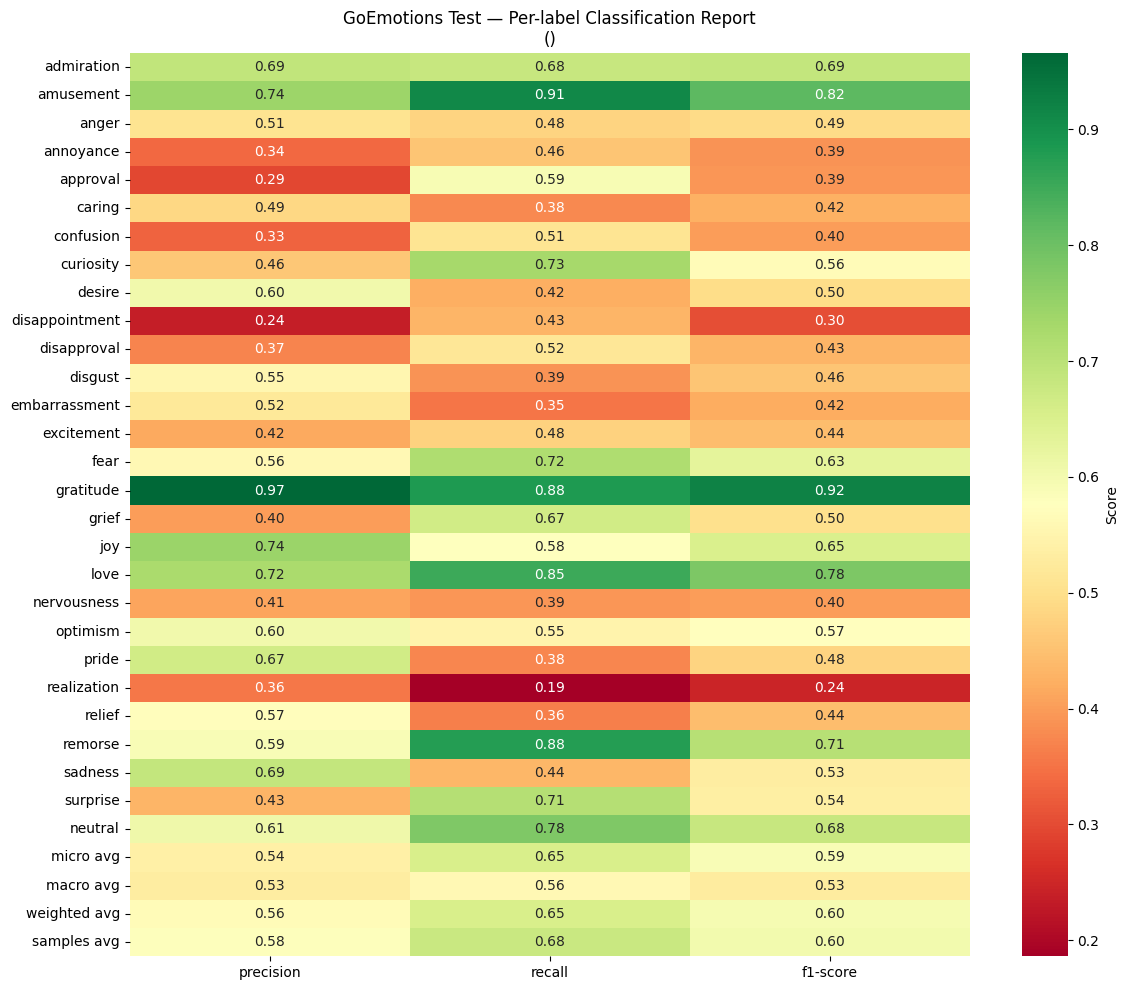


--- Bucketed Classification Report ---
              precision    recall  f1-score   support

    Positive       0.75      0.87      0.81      2098
    Negative       0.65      0.72      0.68      1182
     Neutral       0.78      0.61      0.68      2147

    accuracy                           0.73      5427
   macro avg       0.72      0.73      0.72      5427
weighted avg       0.74      0.73      0.73      5427



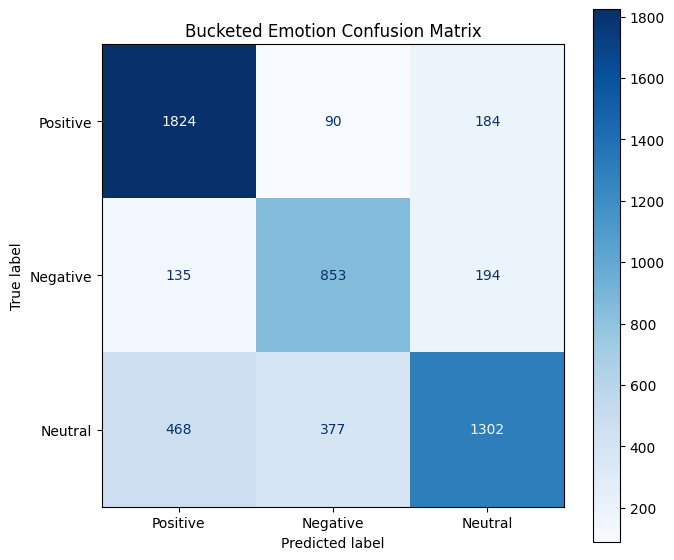

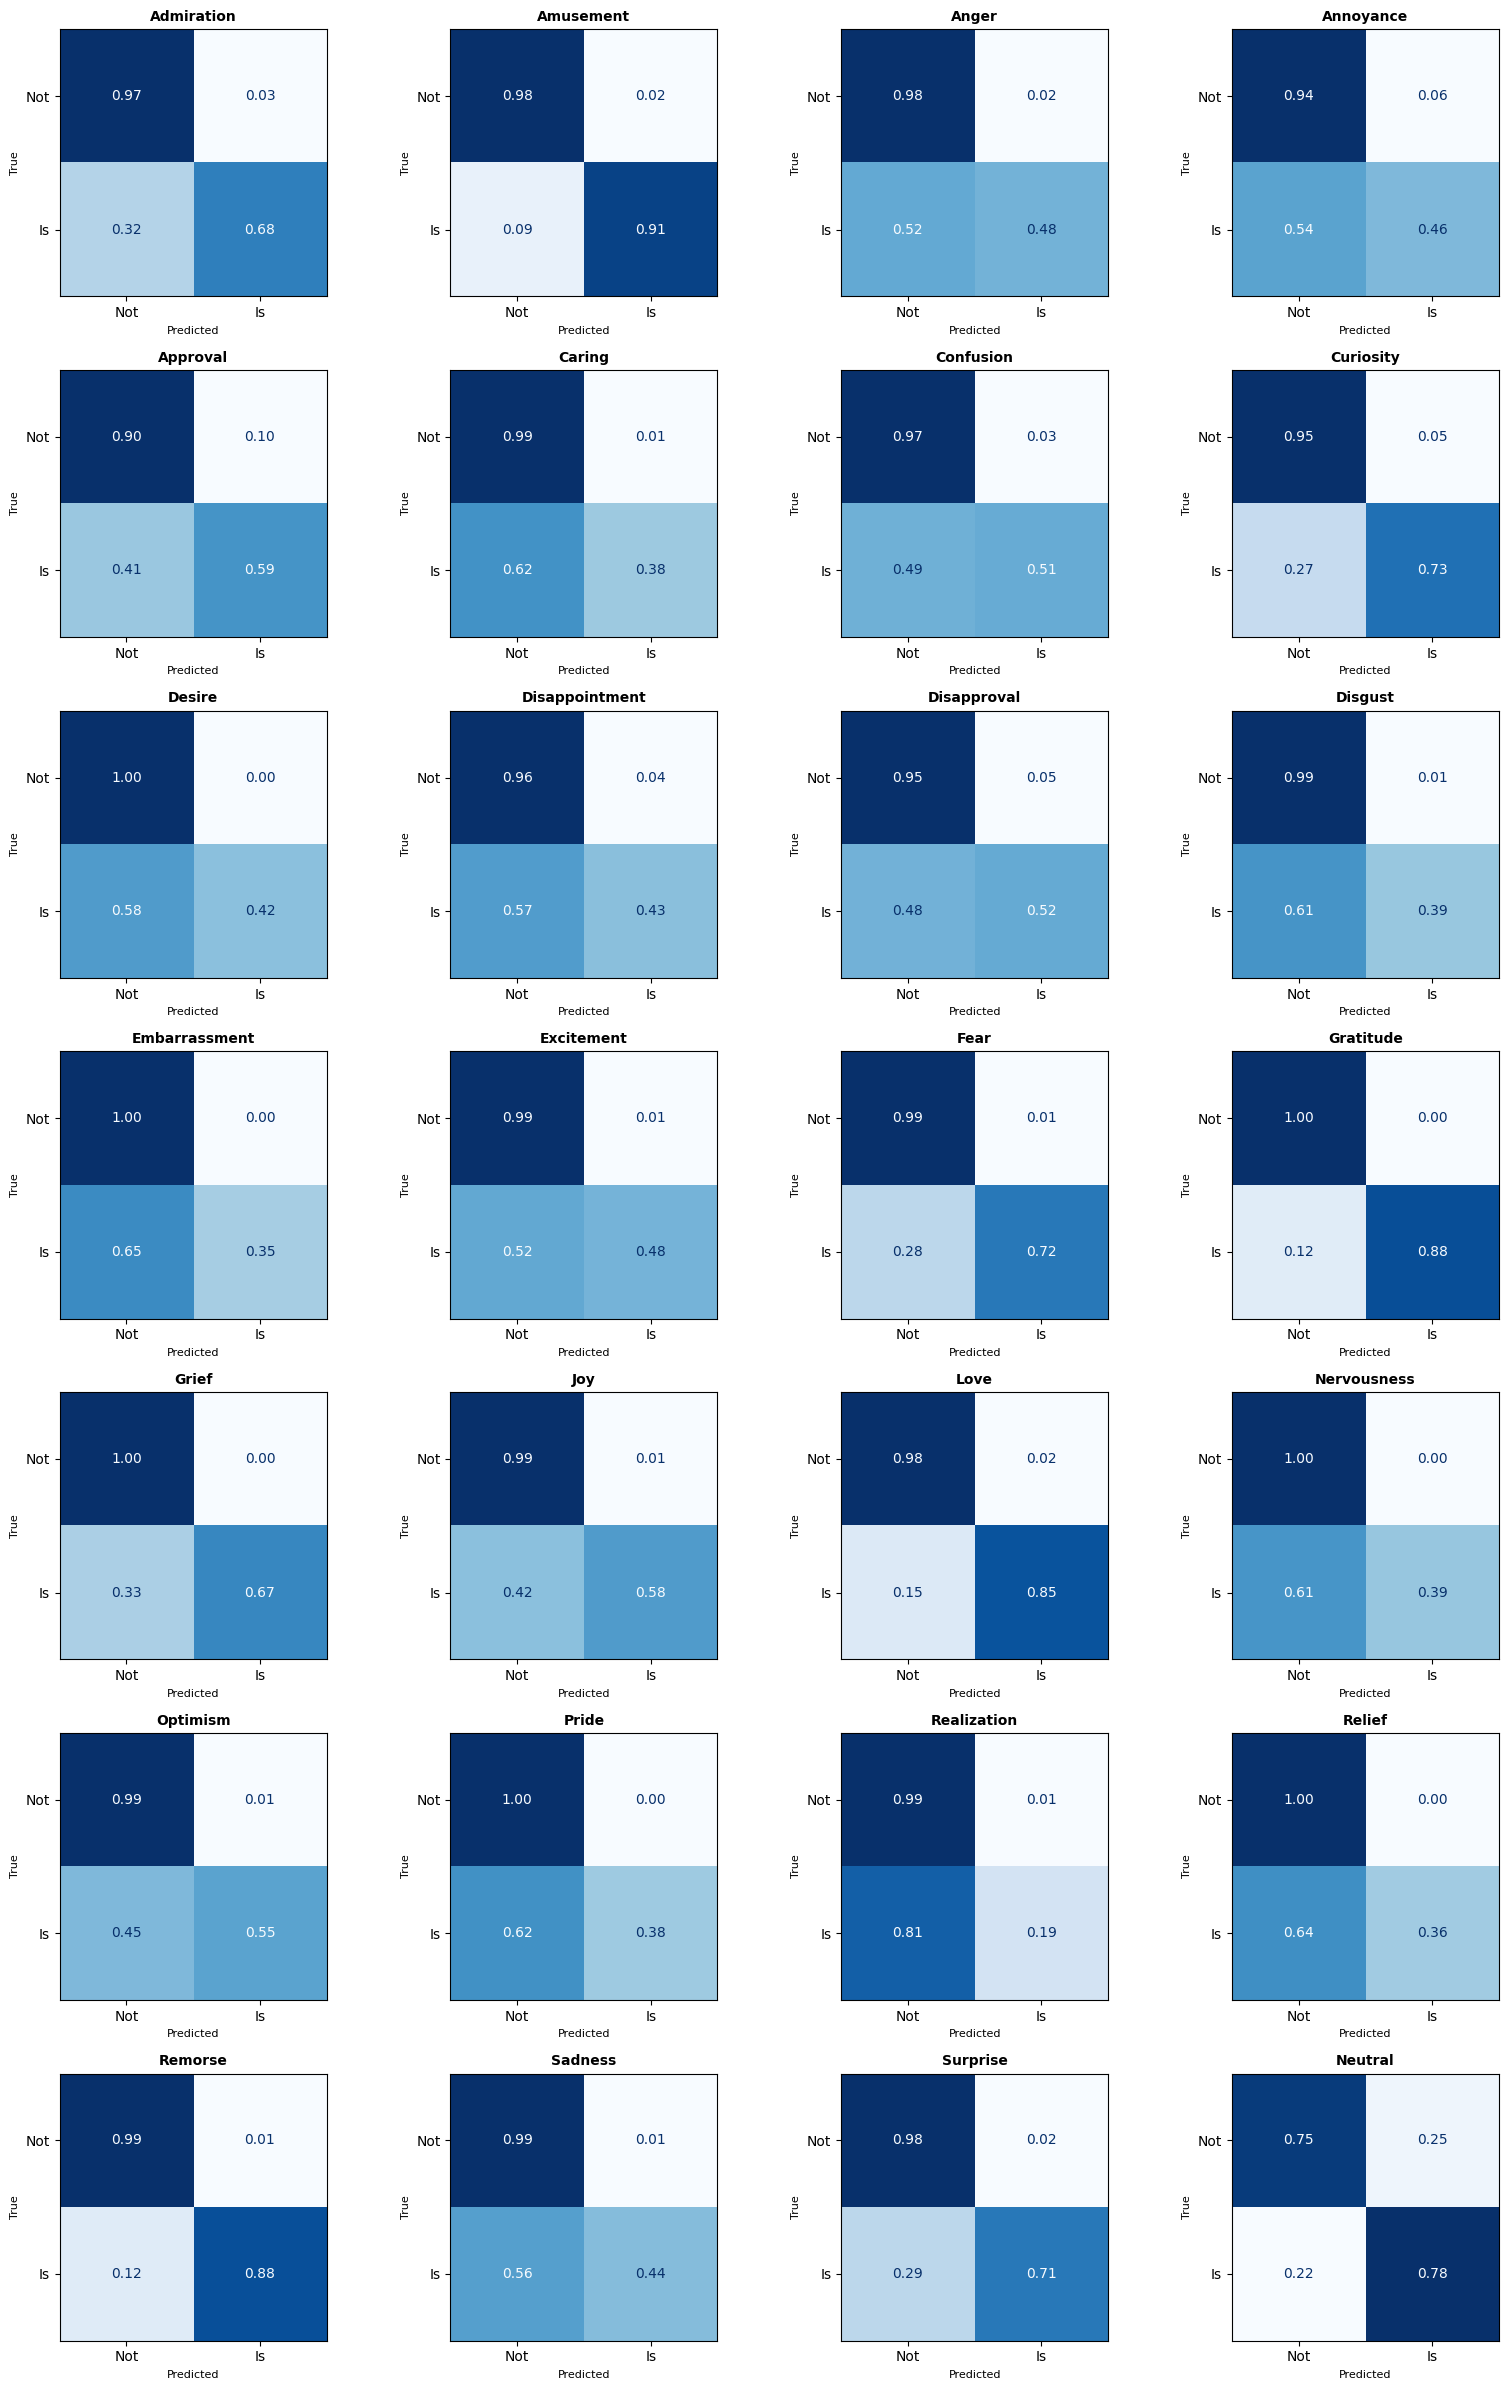

In [11]:
import time

true_labels = np.array(test_dataset["labels"])
test_no_labels = test_dataset.remove_columns("labels")

trainer = Trainer(model=model, data_collator=default_data_collator)

t0 = time.time()
predictions = trainer.predict(test_no_labels)
elapsed = time.time() - t0

logits = predictions.predictions
if isinstance(logits, tuple):
    logits = logits[0]

probs = 1 / (1 + np.exp(-logits))
predicted_labels = (probs >= optimal_thresholds).astype(int)

n = len(test_dataset)
print(f"inference: {elapsed:.2f}s  |  {elapsed/n*1000:.2f} ms/sample  |  {n/elapsed:.0f} samples/sec")

# ── Core metrics ──────────────────────────────────────────────────────────────
macro_f1  = f1_score(true_labels, predicted_labels, average="macro",  zero_division=0)
micro_f1  = f1_score(true_labels, predicted_labels, average="micro",  zero_division=0)
hamming   = hamming_loss(true_labels, predicted_labels)
exact     = np.all(true_labels == predicted_labels, axis=1).mean()

print(f"\nmacro F1:    {macro_f1:.4f}")
print(f"micro F1:    {micro_f1:.4f}")
print(f"hamming:     {hamming:.4f}")
print(f"exact match: {exact:.4f}  ({int(exact*n)}/{n})")

# ── Per-label report + heatmap ────────────────────────────────────────────────
print("\n--- Per-label Classification Report ---")
print(classification_report(true_labels, predicted_labels, target_names=sentimentLabels, zero_division=0))

report_dict = classification_report(true_labels, predicted_labels, target_names=sentimentLabels,
                                    output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

plt.figure(figsize=(12, 10))
sns.heatmap(report_df, annot=True, cmap="RdYlGn", fmt=".2f", cbar_kws={"label": "Score"})
plt.title(f"GoEmotions Test — Per-label Classification Report\n({MODEL_PATH.split('/')[-1]})")
plt.tight_layout()
plt.show()

# ── Bucketed (Positive / Negative / Neutral) ──────────────────────────────────
sentimentMap = {
    "positive": ["admiration", "amusement", "approval", "caring", "desire",
                 "excitement", "gratitude", "joy", "love", "optimism", "pride", "relief"],
    "negative": ["anger", "annoyance", "disappointment", "disapproval", "disgust",
                 "embarrassment", "fear", "grief", "nervousness", "remorse", "sadness"],
    "neutral":  ["neutral", "realization", "surprise", "curiosity", "confusion"]
}

pos_idx = [sentimentLabels.index(e) for e in sentimentMap["positive"] if e in sentimentLabels]
neg_idx = [sentimentLabels.index(e) for e in sentimentMap["negative"] if e in sentimentLabels]
neu_idx = [sentimentLabels.index(e) for e in sentimentMap["neutral"]  if e in sentimentLabels]

def to_buckets(matrix):
    return [np.argmax([matrix[i, pos_idx].sum(), matrix[i, neg_idx].sum(), matrix[i, neu_idx].sum()])
            for i in range(len(matrix))]

y_true_b = to_buckets(true_labels)
y_pred_b = to_buckets(predicted_labels)

print("\n--- Bucketed Classification Report ---")
print(classification_report(y_true_b, y_pred_b, target_names=["Positive", "Negative", "Neutral"], zero_division=0))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_true_b, y_pred_b),
    display_labels=["Positive", "Negative", "Neutral"]
).plot(cmap="Blues", ax=ax)
plt.title("Bucketed Emotion Confusion Matrix")
plt.tight_layout()
plt.show()

# ── Per-label confusion matrices ──────────────────────────────────────────────
mcm = multilabel_confusion_matrix(true_labels, predicted_labels)
fig, axes = plt.subplots(7, 4, figsize=(16, 24))
axes = axes.ravel()
for i, (name, matrix) in enumerate(zip(sentimentLabels, mcm)):
    row_sums = matrix.sum(axis=1)
    normed = np.divide(matrix.astype(float), row_sums[:, np.newaxis],
                       out=np.zeros_like(matrix, dtype=float),
                       where=row_sums[:, np.newaxis] != 0)
    ConfusionMatrixDisplay(confusion_matrix=normed, display_labels=["Not", "Is"]).plot(
        ax=axes[i], cmap="Blues", colorbar=False, values_format=".2f"
    )
    axes[i].set_title(name.capitalize(), fontweight="bold", fontsize=10)
    axes[i].set_xlabel("Predicted", fontsize=8)
    axes[i].set_ylabel("True", fontsize=8)
plt.tight_layout()
plt.show()